PROBLEM 1-a

We want to find the max Von Mises stresses using both CNN and Unet and compare and contrast between the 2 methods.


As per the data given, we can decode that we have 5000 samples (each row of the output file) of the truss which depend on 266 thickness parameters. In each of the sample we have the stress and deformations over 3305 spatial points.


Starting off by importing all the data required, for which I have uploaded all the required data onto Google Drive and I'm importing it from there.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/ME504/stress_0.zip"
#defining path for extraction; uses different format of path when uploading file directly into colab vs uploading through drive"

zipfile.ZipFile is a Python class used to open, read, create, or extract ZIP files. The 'r' parameter makes python open the zip file for reading

In [ ]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/projectdata")
#/content/projectdata defines the path where i'm storing the data in the notebook

excel = "/content/drive/MyDrive/ME504/output.xlsx"
stresses = "/content/projectdata"       #path for the outfile and the stresses

Imprting all the required libraries:

* os: Handles file and folder paths

* glob: Finds multiple files matching patterns like .txt

* pandas: Manages tabular data in Excel files

* MinMaxScaler: Normalizes data values

* Dropout: Randomly disables neurons during training to reduce overfitting




In [ ]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

Now we must read and process the data from both the files. Reading files saves them as dataframes, which are difficult to work it which is why we convert to Numpy.

In [ ]:
outputxlx = pd.read_excel(excel)
print(outputxlx.shape)

X = outputxlx.values   #converting the extracted data into NumPy arrays for easier access through tensorflow

(5000, 226)


Now that all the stress files are extracting and read, we have 5000 individual text files, each with its own path. We must thus compile all the locations of these files

In [ ]:
stressfiles = sorted(
    glob.glob(os.path.join(stresses, "*.txt"))
)

print(len(stressfiles))   #confirming for the right length of the var

5000


In [ ]:
print(os.path.exists(stresses))

print(glob.glob(os.path.join(stresses, "*.txt"))[:5])

stressfiles = sorted(
    glob.glob(os.path.join(stresses, "*.txt"))
)
print(len(stressfiles))

True
['/content/projectdata/stress_4720.txt', '/content/projectdata/stress_274.txt', '/content/projectdata/stress_717.txt', '/content/projectdata/stress_1897.txt', '/content/projectdata/stress_316.txt']
5000


In [ ]:
maxstress = []       #intialising var for max values

for file in stressfiles:
    data = np.loadtxt(file)     #takes output of text file as a Numpy array where each sub array is a row
    stress = data[:, 0]      # takes all rows from column 0 ;First column = Von Mises stress
    max = np.max(stress)
    maxstress.append(max)

maxstress = np.array(maxstress)
print(maxstress.shape)

(5000,)


In [ ]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [ ]:
padding = 256 - 226    #256=16*16 so we're converting to a square fo side 16

X = np.pad(X,((0,0), (0,padding)), mode='constant')     #(0,padding) adds 30 padding after all the exisiting columsn
print(X.shape)


X = X.reshape(-1,16,16,1)             #CNN require input in terms of Height*width*channels which is the shape we're restructuring our data into
print(X.shape)

(5000, 256)
(5000, 16, 16, 1)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
y_scaler = MinMaxScaler()
maxstress = maxstress.reshape(-1,1)
y = y_scaler.fit_transform(maxstress)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model = Sequential()
model.add(Conv2D(32,(3,3),
        activation='relu',
        input_shape=(16,16,1)))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),
        activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())

model.add(Dense(64,
        activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1))

In [ ]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 5, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,329 (138.00 KB)

 Trainable params: 35,329 (138.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train,y_train,epochs=50,batch_size=32,validation_split=0.2, callbacks=[early_stop])

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0112 - mae: 0.0712 - val_loss: 0.0112 - val_mae: 0.0705
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0106 - mae: 0.0688 - val_loss: 0.0112 - val_mae: 0.0686
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0104 - mae: 0.0679 - val_loss: 0.0113 - val_mae: 0.0745
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0102 - mae: 0.0677 - val_loss: 0.0112 - val_mae: 0.0708
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0101 - mae: 0.0666 - val_loss: 0.0112 - val_mae: 0.0697
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0101 - mae: 0.0669 - val_loss: 0.0112 - val_mae: 0.0687
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0099 - mae: 0.0664 - val_loss: 0.0112 - val_mae: 0.0689
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0098 - mae: 0.0665 - val_loss: 0.0113 - val_mae: 0.0675
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/

In [ ]:
loss, mae = model.evaluate(X_test,y_test)
print("Test MAE:", mae)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0098 - mae: 0.0677
Test MAE: 0.06766073405742645


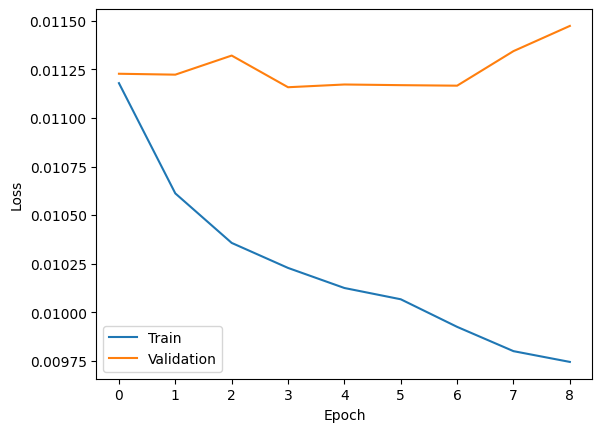

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
print(y.min())
print(y.max())
print(y.mean())

0.0
1.0
0.12928561648169698


In [ ]:
predictions = model.predict(X_test)
pred_real = y_scaler.inverse_transform(predictions)
actual_real = y_scaler.inverse_transform(y_test)

print("Predicted Max Stress:")
print(pred_real[0][0])

print("Actual Max Stress:")
print(actual_real[0][0])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Predicted Max Stress:
9986540.0
Actual Max Stress:
9094219.75618857


In [ ]:
loss, mae = model.evaluate(X_test, y_test)
print(mae)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0098 - mae: 0.0677
0.06766073405742645


## **Approach 2:**

Using U-Net to solve the above problem. U-Net will give a spatial map of maximum stress at each node, as compared to CNN which will give the maximum overall stress.
U-Net is a specialised CNN frameowrk, so we use that to model our approach.

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Conv2DTranspose, concatenate
from tensorflow.keras.optimizers import Adam

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#remounting my google drive...check if we can use the same one and how

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

 0811.mp4
 2024MEB1384_Instrumentation.gdoc
 2024MEB1384.JPG
'2024MEB1384_Photoelastic transmission.gdoc'
 2024MEB1384_ThinCylinders.gdoc
'2026 project .gdoc'
 7ebec4e4712ae15af01017a373665fd8.jpg
 8fbdc9924e5cbd7e4796620b187851b2.jpg
'Art Stuff'
 Assignment4_Report.gdoc
 Books
'CC day 1.gdoc'
'CC PANEL DISCUSSION DAY -1.gdoc'
'Chem project speedrun edition.gdoc'
'Colab Notebooks'
'Copy of Energy Recharge Calculator.gsheet'
'Crisis Update.gdoc'
'Eloquence’26 judging sheets.gdoc'
'Eloquence’26 judging sheets.pdf'
 Enarrators.gdoc
'Enarrators proposal for IIT Delhi (1).pdf'
'Enarrators proposal for IIT Delhi.gdoc'
'Enarrators proposal for IIT Delhi.pdf'
'From the reading community...gdoc'
'GC Raavi Dance'
 ge101.gdoc
'GE101 Report (1).pdf'
'GE101 Report.pdf'
'[GE109]2024MEB1384 .gdoc'
 GE109_SanviShripad_AdditiveManufacturing.gdoc
'geostrategic odessy.gdoc'
'geostrategic odyssey.gdoc'
 grateful.gdoc
'IIT Ropar Sanvi first Samester fee 20July2024 v1.pdf'
'IIT Ropar Sanvi first Samester Me

In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/DL Project'))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/DL Project'

In [ ]:
#loading the data set
excel_path = '/content/drive/MyDrive/DL Project/output.xlsx'

df = pd.read_excel(excel_path)
X = df.iloc[:, :226].values #selecting the first 226 columns
print(X.shape)

In [ ]:
#load stress field lines
stress_folder = '/content/drive/MyDrive/DL Project/stress_folder'

Y = []

files = sorted(os.listdir(stress_folder))

for file in files:
    data = np.loadtxt(os.path.join(stress_folder, file))

    stress = data[:, 0] #extracting the first column for Von Misses Stresses

    Y.append(stress)

Y = np.array(Y) #Converts list to matrix

print(Y.shape)

In [ ]:
coords = np.loadtxt('/content/drive/MyDrive/DL Project/cord.txt')
print(coords.shape)
print(coords[:10])

x_coords = coords[:,1]
y_coords = coords[:,2]

print("Unique X:", len(np.unique(x_coords)))
print("Unique Y:", len(np.unique(y_coords)))

We assume that each of the 226 thickness variables controls a local region of the 3304-point mesh.

Then we can distribute each thickness value to nearby mesh coordinates using interpolation / nearest-neighbor assignment.

so, build a coarse 226-point virtual grid
Use coordinate interpolation to project those values onto the 3304 FEM coordinates

In [ ]:
#normalise the input
#thickness values may have different scales, so we convert it into normal distribution with mean = 0 and std = 1
#basically to stabilise the data

scaler = StandardScaler()
X = scaler.fit_transform(X)

#reshape input/output to match the actual node layout
#first to find node locations
coords = np.loadtxt('/content/drive/MyDrive/DL Project/cord.txt')

print(coords.shape)

x_mesh = coords[:,1]
y_mesh = coords[:,2]

#normalise the coordinates
x_mesh = (x_mesh - x_mesh.min()) / (x_mesh.max() - x_mesh.min())
y_mesh = (y_mesh - y_mesh.min()) / (y_mesh.max() - y_mesh.min())

#defining a grid for 226
design_h = 14
design_w = 17
x_design = np.linspace(0,1,design_w) #creating their virtual positions
y_design = np.linspace(0,1,design_h)
X_design_grid, Y_design_grid = np.meshgrid(x_design, y_design)

#flatten design coordinates
design_points = np.column_stack([
    X_design_grid.ravel(),
    Y_design_grid.ravel()
])
# .revel() converts a multi-dimensional NumPy array into a 1D array without copying data if possible (more memory-efficient than .flatten())

#for each of the 3304 points, this will now find the nearest deisgn variable to map it's value to
from scipy.spatial import cKDTree
#cKD Tree is for implementing a k-dimensional tree for spatial searches

tree = cKDTree(design_points[:226])

mesh_points = np.column_stack([x_mesh, y_mesh])

_, nearest_idx = tree.query(mesh_points)

X_grid = np.zeros((5000, 3304, 1))

for sample in range(5000):
    X_grid[sample,:,0] = X[sample, nearest_idx]

print(X_grid.shape)

#mapping the stress
Y_grid = Y.reshape(5000,3304,1)
X_grid = X_grid.reshape(5000,56,59,1)
Y_grid = Y_grid.reshape(5000,56,59,1)

print(X_grid.shape)
print(Y_grid.shape)

plt.figure(figsize=(10,6))
plt.imshow(X_grid[0,:,:,0], cmap='viridis')
plt.colorbar()
plt.title("Mapped Thickness Field")
plt.show()

plt.figure(figsize=(10,6))
plt.imshow(Y_grid[0,:,:,0], cmap='viridis')
plt.colorbar()
plt.title("Mapped Stress Field")
plt.show()



In [ ]:
#padding layer into 64x64 for operations later
X_pad = np.zeros((5000,64,64,1))
Y_pad = np.zeros((5000,64,64,1))

X_pad[:,:56,:59,:] = X_grid
Y_pad[:,:56,:59,:] = Y_grid

X = X_pad
Y = Y_pad

print(X.shape)
print(Y.shape)

In [ ]:
plt.figure(figsize=(8,5))
plt.imshow(X[0,:,:,0], cmap='viridis')
plt.colorbar()
plt.title("Mapped Thickness Field")
plt.show()

plt.figure(figsize=(8,5))
plt.imshow(Y[0,:,:,0], cmap='viridis')
plt.colorbar()
plt.title("Stress Field")
plt.show()

In [ ]:
#Normalising the values of thickness as well
X = X / np.mean(X)
Y = Y / np.mean(Y)

#splitting into testing(20%) and training data
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [ ]:
inputs = Input((64,64,1))

# Encoder
c1 = Conv2D(64,(3,3),activation='relu',padding='same')(inputs)
#32 filters, of size (3 x 3) with activation function as ReLU in this convolution layer. Since padding is kept the same, entire image will still be of size 64 x 64
c1 = Conv2D(64,(3,3),activation='relu',padding='same')(c1)
p1 = MaxPooling2D((2,2))(c1)

c2 = Conv2D(128,(3,3),activation='relu',padding='same')(p1)
c2 = Conv2D(128,(3,3),activation='relu',padding='same')(c2)
p2 = MaxPooling2D((2,2))(c2)

# Bottleneck
c3 = Conv2D(256,(3,3),activation='relu',padding='same')(p2)
c3 = Conv2D(256,(3,3),activation='relu',padding='same')(c3)

# Decoder
u1 = Conv2DTranspose(128,(2,2),strides=(2,2),padding='same')(c3)
u1 = concatenate([u1,c2])

c4 = Conv2D(128,(3,3),activation='relu',padding='same')(u1)
c4 = Conv2D(128,(3,3),activation='relu',padding='same')(c4)

u2 = Conv2DTranspose(64,(2,2),strides=(2,2),padding='same')(c4)
u2 = concatenate([u2,c1])

c5 = Conv2D(64,(3,3),activation='relu',padding='same')(u2)
c5 = Conv2D(64,(3,3),activation='relu',padding='same')(c5)

outputs = Conv2D(1,(1,1),activation='linear')(c5)

model = Model(inputs, outputs)

model.summary()

In [ ]:
#compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [ ]:
#train
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1
)

In [ ]:
#evaluate
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test MAE:", mae)

In [ ]:
print(Y.min())
print(Y.max())
print(Y.mean())

In [ ]:
#predict stress field
predictions = model.predict(X_test)

print(predictions.shape)

In [ ]:
#calculate maximum stress
pred_max = np.max(predictions, axis=(1,2,3))
true_max = np.max(y_test, axis=(1,2,3))

In [ ]:
#compare the results
error = np.mean(np.abs(pred_max - true_max))

print("Maximum Stress MAE =", error)

In [ ]:
# Plot epochs vs. loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()